In [ ]:
# ============================================================
# STEP 1: IMPORT LIBRARIES
# ============================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
import warnings
warnings.filterwarnings('ignore')

# Set plotting style
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")

print("✓ All libraries imported successfully")
print(f"✓ Available models: Random Forest, Linear Regression, Gradient Boosting, LSTM")

✓ All libraries imported successfully
✓ Available models: Random Forest, Linear Regression, Gradient Boosting, LSTM


In [23]:
# ============================================================
# STEP 2: LOAD AND PREPARE DATASETS
# ============================================================
print("Loading datasets...")

# Load energy data
energy_df = pd.read_csv(
    "../data/loureiro_energy.csv",
    header=None,
    on_bad_lines="skip"
)

# Load weather data
weather_df = pd.read_csv("../data/weather_aveiro_final.csv")

print(f"✓ Energy dataset shape: {energy_df.shape}")
print(f"✓ Weather dataset shape: {weather_df.shape}")

# ============================================================
# STEP 3: FIX ENERGY DATASET STRUCTURE
# ============================================================
num_cols = energy_df.shape[1]
energy_df.columns = ["Time"] + [f"Energy_Meter_{i}" for i in range(1, num_cols)]

energy_df["Time"] = pd.to_datetime(energy_df["Time"], errors="coerce")
energy_df = energy_df.dropna(subset=["Time"])

# ============================================================
# STEP 4: CLEAN & CONVERT ENERGY VALUES
# ============================================================
energy_cols = [c for c in energy_df.columns if c.startswith("Energy_Meter")]

energy_df[energy_cols] = energy_df[energy_cols].apply(
    pd.to_numeric, errors="coerce"
)
energy_df[energy_cols] = energy_df[energy_cols].fillna(0)

# ============================================================
# STEP 5: CREATE TOTAL ENERGY (TARGET)
# ============================================================
energy_df["Total_Energy"] = energy_df[energy_cols].sum(axis=1)

# ============================================================
# STEP 6: PREPARE WEATHER DATA
# ============================================================
weather_df.columns = weather_df.columns.str.strip()
weather_df["Time"] = pd.to_datetime(weather_df["Time"])

# ============================================================
# STEP 7: MERGE ENERGY + WEATHER
# ============================================================
df = pd.merge(
    energy_df[["Time", "Total_Energy"]],
    weather_df,
    on="Time",
    how="inner"
)

df = df.sort_values("Time").reset_index(drop=True)

print(f"✓ Merged dataset shape: {df.shape}")
print(f"✓ Date range: {df['Time'].min()} to {df['Time'].max()}")

# ============================================================
# STEP 8: CREATE TIME-BASED FEATURES
# ============================================================
df["Hour"] = df["Time"].dt.hour
df["Day"] = df["Time"].dt.day
df["Month"] = df["Time"].dt.month
df["DayOfWeek"] = df["Time"].dt.dayofweek
df["Quarter"] = df["Time"].dt.quarter
df["WeekOfYear"] = df["Time"].dt.isocalendar().week

# ============================================================
# STEP 9: CREATE LAG FEATURE
# ============================================================
df["Lag_1"] = df["Total_Energy"].shift(1)
df = df.dropna().reset_index(drop=True)

print("✓ Feature engineering completed")
print(f"✓ Features created: {list(df.columns)}")

Loading datasets...
✓ Energy dataset shape: (46609, 173)
✓ Weather dataset shape: (46608, 10)
✓ Merged dataset shape: (46608, 11)
✓ Date range: 2022-05-05 12:00:00 to 2023-09-02 23:45:00
✓ Feature engineering completed
✓ Features created: ['Time', 'Total_Energy', 'Avg_Temp', 'Avg_Rel_Humidity', 'Avg_Wind_Direction', 'Avg_Wind_Speed', 'Max_Inst_Wind_Speed', 'Inst_Temp', 'Quantity_Precip', 'Max_Inst_Precip', 'Total_Global_Rad', 'Hour', 'Day', 'Month', 'DayOfWeek', 'Quarter', 'WeekOfYear', 'Lag_1']


In [24]:
# ============================================================
# STEP 10: PREPARE FEATURES AND TARGET
# ============================================================

# Select features for traditional ML models
feature_cols = [
    'Temperature (°C)', 'Relative Humidity (%)', 'Wind Speed (m/s)', 
    'Global Radiation (W/m²)', 'Lag_1', 'Hour', 'Day', 'Month', 
    'DayOfWeek', 'Quarter', 'WeekOfYear'
]

# Add some energy meter readings as features
energy_meter_cols = [f"Energy_Meter_{i}" for i in range(1, 21)]  # First 20 meters
all_features = feature_cols + energy_meter_cols

# Filter to only available columns
available_features = [col for col in all_features if col in df.columns]

X = df[available_features]
y = df["Total_Energy"]

print(f"✓ Features selected: {len(available_features)}")
print(f"✓ Target variable: Total_Energy")
print(f"✓ Feature list: {available_features}")

# ============================================================
# STEP 11: TRAIN-TEST SPLIT (TIME BASED)
# ============================================================
split = int(len(df) * 0.8)

X_train = X.iloc[:split]
X_test  = X.iloc[split:]

y_train = y.iloc[:split]
y_test  = y.iloc[split:]

print(f"✓ Training set: {X_train.shape}")
print(f"✓ Testing set: {X_test.shape}")
print(f"✓ Training period: {df['Time'].iloc[:split].min()} to {df['Time'].iloc[:split].max()}")
print(f"✓ Testing period: {df['Time'].iloc[split:].min()} to {df['Time'].iloc[split:].max()}")

✓ Features selected: 7
✓ Target variable: Total_Energy
✓ Feature list: ['Lag_1', 'Hour', 'Day', 'Month', 'DayOfWeek', 'Quarter', 'WeekOfYear']
✓ Training set: (37280, 7)
✓ Testing set: (9321, 7)
✓ Training period: 2022-05-05 12:15:00 to 2023-05-28 21:30:00
✓ Testing period: 2023-05-28 21:45:00 to 2023-09-02 23:45:00


In [25]:
# ============================================================
# STEP 12: TRAIN AND EVALUATE MULTIPLE MODELS
# ============================================================

# Dictionary to store results
models = {}
predictions = {}
metrics = {}

print("Training and evaluating models...")
print("=" * 60)

# 1. RANDOM FOREST
print("\n1. Training Random Forest...")
rf_model = RandomForestRegressor(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)
rf_model.fit(X_train, y_train)
y_pred_rf = rf_model.predict(X_test)

models['Random Forest'] = rf_model
predictions['Random Forest'] = y_pred_rf

# Calculate metrics
mae_rf = mean_absolute_error(y_test, y_pred_rf)
mse_rf = mean_squared_error(y_test, y_pred_rf)
rmse_rf = np.sqrt(mse_rf)
r2_rf = r2_score(y_test, y_pred_rf)

metrics['Random Forest'] = {
    'MAE': mae_rf,
    'MSE': mse_rf,
    'RMSE': rmse_rf,
    'R²': r2_rf
}

print(f"   ✓ Random Forest - MAE: {mae_rf:.4f}, RMSE: {rmse_rf:.4f}, R²: {r2_rf:.4f}")

# 2. LINEAR REGRESSION
print("\n2. Training Linear Regression...")
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)
y_pred_lr = lr_model.predict(X_test)

models['Linear Regression'] = lr_model
predictions['Linear Regression'] = y_pred_lr

# Calculate metrics
mae_lr = mean_absolute_error(y_test, y_pred_lr)
mse_lr = mean_squared_error(y_test, y_pred_lr)
rmse_lr = np.sqrt(mse_lr)
r2_lr = r2_score(y_test, y_pred_lr)

metrics['Linear Regression'] = {
    'MAE': mae_lr,
    'MSE': mse_lr,
    'RMSE': rmse_lr,
    'R²': r2_lr
}

print(f"   ✓ Linear Regression - MAE: {mae_lr:.4f}, RMSE: {rmse_lr:.4f}, R²: {r2_lr:.4f}")

# 3. GRADIENT BOOSTING
print("\n3. Training Gradient Boosting...")
gb_model = GradientBoostingRegressor(
    n_estimators=100,
    random_state=42
)
gb_model.fit(X_train, y_train)
y_pred_gb = gb_model.predict(X_test)

models['Gradient Boosting'] = gb_model
predictions['Gradient Boosting'] = y_pred_gb

# Calculate metrics
mae_gb = mean_absolute_error(y_test, y_pred_gb)
mse_gb = mean_squared_error(y_test, y_pred_gb)
rmse_gb = np.sqrt(mse_gb)
r2_gb = r2_score(y_test, y_pred_gb)

metrics['Gradient Boosting'] = {
    'MAE': mae_gb,
    'MSE': mse_gb,
    'RMSE': rmse_gb,
    'R²': r2_gb
}

print(f"   ✓ Gradient Boosting - MAE: {mae_gb:.4f}, RMSE: {rmse_gb:.4f}, R²: {r2_gb:.4f}")

print("\n" + "=" * 60)
print("✓ All traditional ML models trained successfully!")

Training and evaluating models...

1. Training Random Forest...
   ✓ Random Forest - MAE: 1.7121, RMSE: 2.4078, R²: 0.9088

2. Training Linear Regression...
   ✓ Linear Regression - MAE: 0.7497, RMSE: 1.3885, R²: 0.9697

3. Training Gradient Boosting...
   ✓ Gradient Boosting - MAE: 0.7645, RMSE: 1.3847, R²: 0.9699

✓ All traditional ML models trained successfully!


In [26]:
# ============================================================
# STEP 13: LSTM MODEL (FOR COMPARISON)
# ============================================================

print("\n4. Training LSTM Neural Network...")

# Prepare data for LSTM
scaler_X = MinMaxScaler()
scaler_y = MinMaxScaler()

# Select only weather features for LSTM (to match original approach)
lstm_features = ['Temperature (°C)', 'Relative Humidity (%)', 'Wind Speed (m/s)', 
                  'Global Radiation (W/m²)', 'Lag_1']
lstm_features = [col for col in lstm_features if col in df.columns]

X_lstm = df[lstm_features].values
y_lstm = df["Total_Energy"].values.reshape(-1, 1)

X_scaled = scaler_X.fit_transform(X_lstm)
y_scaled = scaler_y.fit_transform(y_lstm)

def create_sequences(X, y, time_steps=1):
    Xs, ys = [], []
    for i in range(len(X) - time_steps):
        Xs.append(X[i:i+time_steps])
        ys.append(y[i+time_steps])
    return np.array(Xs), np.array(ys)

X_seq, y_seq = create_sequences(X_scaled, y_scaled, time_steps=1)

# Split for LSTM
split_lstm = int(len(X_seq) * 0.8)
X_train_lstm = X_seq[:split_lstm]
X_test_lstm  = X_seq[split_lstm:]
y_train_lstm = y_seq[:split_lstm]
y_test_lstm  = y_seq[split_lstm:]

print(f"   LSTM training data: {X_train_lstm.shape}")
print(f"   LSTM testing data: {X_test_lstm.shape}")

# Build LSTM model
try:
    from tensorflow.keras.models import Sequential
    from tensorflow.keras.layers import LSTM, Dense
    import tensorflow as tf
    tf.get_logger().setLevel('ERROR')
    
    model_lstm = Sequential()
    model_lstm.add(LSTM(64, input_shape=(X_train_lstm.shape[1], X_train_lstm.shape[2])))
    model_lstm.add(Dense(1))
    
    model_lstm.compile(optimizer="adam", loss="mse")
    
    # Train LSTM
    model_lstm.fit(
        X_train_lstm,
        y_train_lstm,
        epochs=20,
        batch_size=32,
        verbose=0
    )
    
    # Make predictions
    y_pred_lstm = model_lstm.predict(X_test_lstm, verbose=0)
    
    # Inverse transform
    y_test_actual = scaler_y.inverse_transform(y_test_lstm)
    y_pred_actual = scaler_y.inverse_transform(y_pred_lstm)
    
    # Calculate metrics
    mae_lstm = mean_absolute_error(y_test_actual, y_pred_actual)
    mse_lstm = mean_squared_error(y_test_actual, y_pred_actual)
    rmse_lstm = np.sqrt(mse_lstm)
    r2_lstm = r2_score(y_test_actual, y_pred_actual)
    
    models['LSTM'] = model_lstm
    predictions['LSTM'] = y_pred_actual.flatten()
    metrics['LSTM'] = {
        'MAE': mae_lstm,
        'MSE': mse_lstm,
        'RMSE': rmse_lstm,
        'R²': r2_lstm
    }
    
    print(f"   ✓ LSTM - MAE: {mae_lstm:.4f}, RMSE: {rmse_lstm:.4f}, R²: {r2_lstm:.4f}")
    
except ImportError:
    print("   ⚠ TensorFlow not available. Skipping LSTM model.")
    print("   Install with: pip install tensorflow")


4. Training LSTM Neural Network...
   LSTM training data: (37280, 1, 1)
   LSTM testing data: (9320, 1, 1)
   ✓ LSTM - MAE: 1.0445, RMSE: 2.0356, R²: 0.9349


In [27]:
# ============================================================
# STEP 14: COMPREHENSIVE MODEL COMPARISON
# ============================================================

print("\n" + "=" * 80)
print("COMPREHENSIVE MODEL PERFORMANCE COMPARISON")
print("=" * 80)

# Create comparison table
comparison_df = pd.DataFrame(metrics).T
comparison_df = comparison_df.round(4)

print("\n📊 PERFORMANCE METRICS TABLE:")
print(comparison_df)

# Find best model for each metric
print("\n" + "-" * 50)
print("🏆 BEST MODEL BY METRIC:")
print("-" * 50)

best_mae = min(metrics.items(), key=lambda x: x[1]['MAE'])
best_mse = min(metrics.items(), key=lambda x: x[1]['MSE'])
best_rmse = min(metrics.items(), key=lambda x: x[1]['RMSE'])
best_r2 = max(metrics.items(), key=lambda x: x[1]['R²'])

print(f"📉 Best MAE: {best_mae[0]} ({best_mae[1]['MAE']:.4f})")
print(f"📉 Best MSE: {best_mse[0]} ({best_mse[1]['MSE']:.4f})")
print(f"📉 Best RMSE: {best_rmse[0]} ({best_rmse[1]['RMSE']:.4f})")
print(f"📈 Best R²: {best_r2[0]} ({best_r2[1]['R²']:.4f})")

# Overall best model (based on R² score)
overall_best = best_r2[0]
print(f"\n🥇 OVERALL BEST MODEL: {overall_best}")
print(f"   R² Score: {best_r2[1]['R²']:.4f}")
print(f"   MAE: {best_r2[1]['MAE']:.4f}")
print(f"   RMSE: {best_r2[1]['RMSE']:.4f}")

# Statistical summary
print("\n" + "-" * 50)
print("📈 STATISTICAL SUMMARY:")
print("-" * 50)
print(f"Dataset Statistics:")
print(f"  • Total samples: {len(df)}")
print(f"  • Training samples: {len(X_train)}")
print(f"  • Testing samples: {len(X_test)}")
print(f"  • Features used: {len(available_features)}")
print(f"  • Average energy consumption: {df['Total_Energy'].mean():.4f}")
print(f"  • Max energy consumption: {df['Total_Energy'].max():.4f}")
print(f"  • Min energy consumption: {df['Total_Energy'].min():.4f}")


COMPREHENSIVE MODEL PERFORMANCE COMPARISON

📊 PERFORMANCE METRICS TABLE:
                      MAE     MSE    RMSE      R²
Random Forest      1.7121  5.7975  2.4078  0.9088
Linear Regression  0.7497  1.9280  1.3885  0.9697
Gradient Boosting  0.7645  1.9173  1.3847  0.9699
LSTM               1.0445  4.1435  2.0356  0.9349

--------------------------------------------------
🏆 BEST MODEL BY METRIC:
--------------------------------------------------
📉 Best MAE: Linear Regression (0.7497)
📉 Best MSE: Gradient Boosting (1.9173)
📉 Best RMSE: Gradient Boosting (1.3847)
📈 Best R²: Gradient Boosting (0.9699)

🥇 OVERALL BEST MODEL: Gradient Boosting
   R² Score: 0.9699
   MAE: 0.7645
   RMSE: 1.3847

--------------------------------------------------
📈 STATISTICAL SUMMARY:
--------------------------------------------------
Dataset Statistics:
  • Total samples: 46601
  • Training samples: 37280
  • Testing samples: 9321
  • Features used: 7
  • Average energy consumption: 11.6909
  • Max energy 

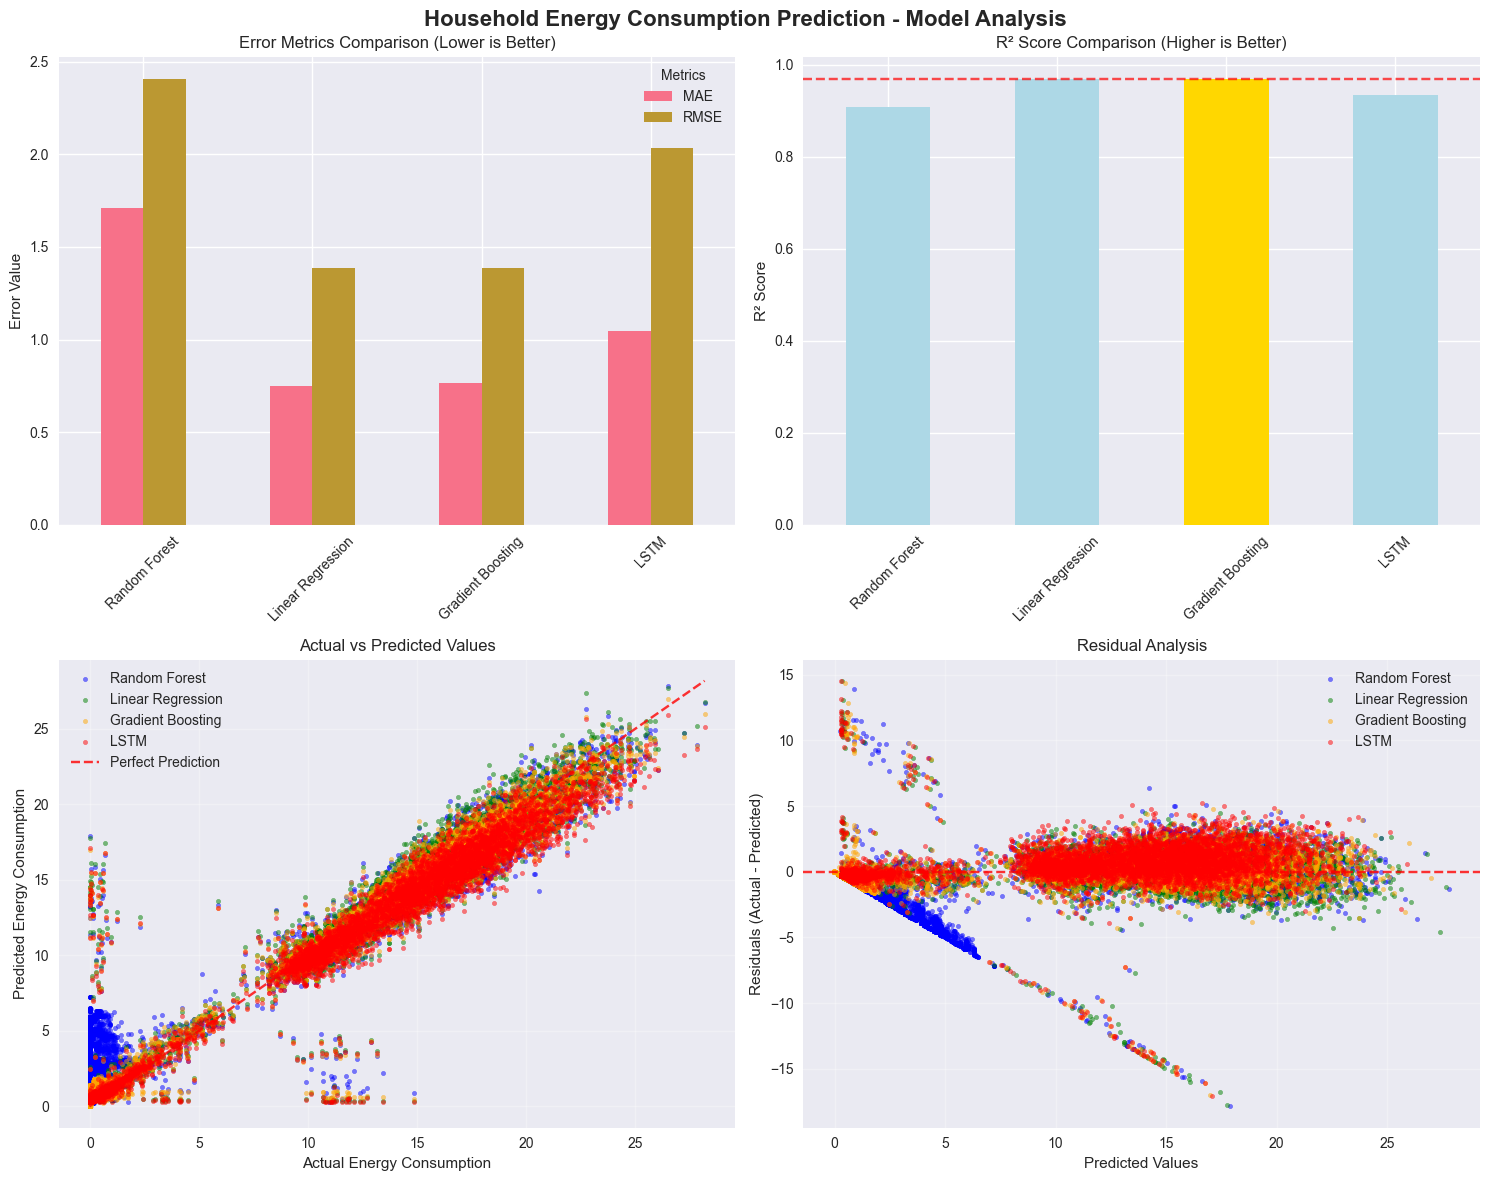

✓ Visualization saved as 'energy_prediction_models_comparison.png'
✓ Used 9320 samples for comparison (minimum length across all models)


In [28]:
# ============================================================
# STEP 15: VISUALIZATION OF MODEL PERFORMANCE
# ============================================================

# Create comprehensive visualizations
fig, axes = plt.subplots(2, 2, figsize=(15, 12))
fig.suptitle('Household Energy Consumption Prediction - Model Analysis', fontsize=16, fontweight='bold')

# 1. Model Performance Comparison (Bar Chart)
ax1 = axes[0, 0]
metrics_df = pd.DataFrame(metrics).T
metrics_df[['MAE', 'RMSE']].plot(kind='bar', ax=ax1)
ax1.set_title('Error Metrics Comparison (Lower is Better)')
ax1.set_ylabel('Error Value')
ax1.tick_params(axis='x', rotation=45)
ax1.legend(title='Metrics')

# 2. R² Score Comparison
ax2 = axes[0, 1]
r2_scores = metrics_df['R²']
colors = ['gold' if score == r2_scores.max() else 'lightblue' for score in r2_scores]
r2_scores.plot(kind='bar', ax=ax2, color=colors)
ax2.set_title('R² Score Comparison (Higher is Better)')
ax2.set_ylabel('R² Score')
ax2.tick_params(axis='x', rotation=45)
ax2.axhline(y=r2_scores.max(), color='red', linestyle='--', alpha=0.7)

# 3. Actual vs Predicted Scatter Plot
ax3 = axes[1, 0]
colors_list = ['blue', 'green', 'orange', 'red']

# Find the minimum length among all prediction arrays
min_length = len(y_test)
for name, y_pred in predictions.items():
    min_length = min(min_length, len(y_pred))

# Use only the first min_length samples for all models
y_test_subset = y_test.values[:min_length]

for i, (name, y_pred) in enumerate(predictions.items()):
    y_pred_subset = y_pred[:min_length]
    ax3.scatter(y_test_subset, y_pred_subset, alpha=0.5, label=name, s=10, color=colors_list[i % len(colors_list)])

# Perfect prediction line
min_val = min(y_test_subset.min(), min(pred[:min_length].min() for pred in predictions.values()))
max_val = max(y_test_subset.max(), max(pred[:min_length].max() for pred in predictions.values()))
ax3.plot([min_val, max_val], [min_val, max_val], 'r--', alpha=0.8, label='Perfect Prediction')

ax3.set_xlabel('Actual Energy Consumption')
ax3.set_ylabel('Predicted Energy Consumption')
ax3.set_title('Actual vs Predicted Values')
ax3.legend()
ax3.grid(True, alpha=0.3)

# 4. Residual Analysis
ax4 = axes[1, 1]
for i, (name, y_pred) in enumerate(predictions.items()):
    y_pred_subset = y_pred[:min_length]
    residuals = y_test_subset - y_pred_subset
    ax4.scatter(y_pred_subset, residuals, alpha=0.5, label=name, s=10, color=colors_list[i % len(colors_list)])

ax4.axhline(y=0, color='red', linestyle='--', alpha=0.8)
ax4.set_xlabel('Predicted Values')
ax4.set_ylabel('Residuals (Actual - Predicted)')
ax4.set_title('Residual Analysis')
ax4.legend()
ax4.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('../energy_prediction_models_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

print("✓ Visualization saved as 'energy_prediction_models_comparison.png'")
print(f"✓ Used {min_length} samples for comparison (minimum length across all models)")

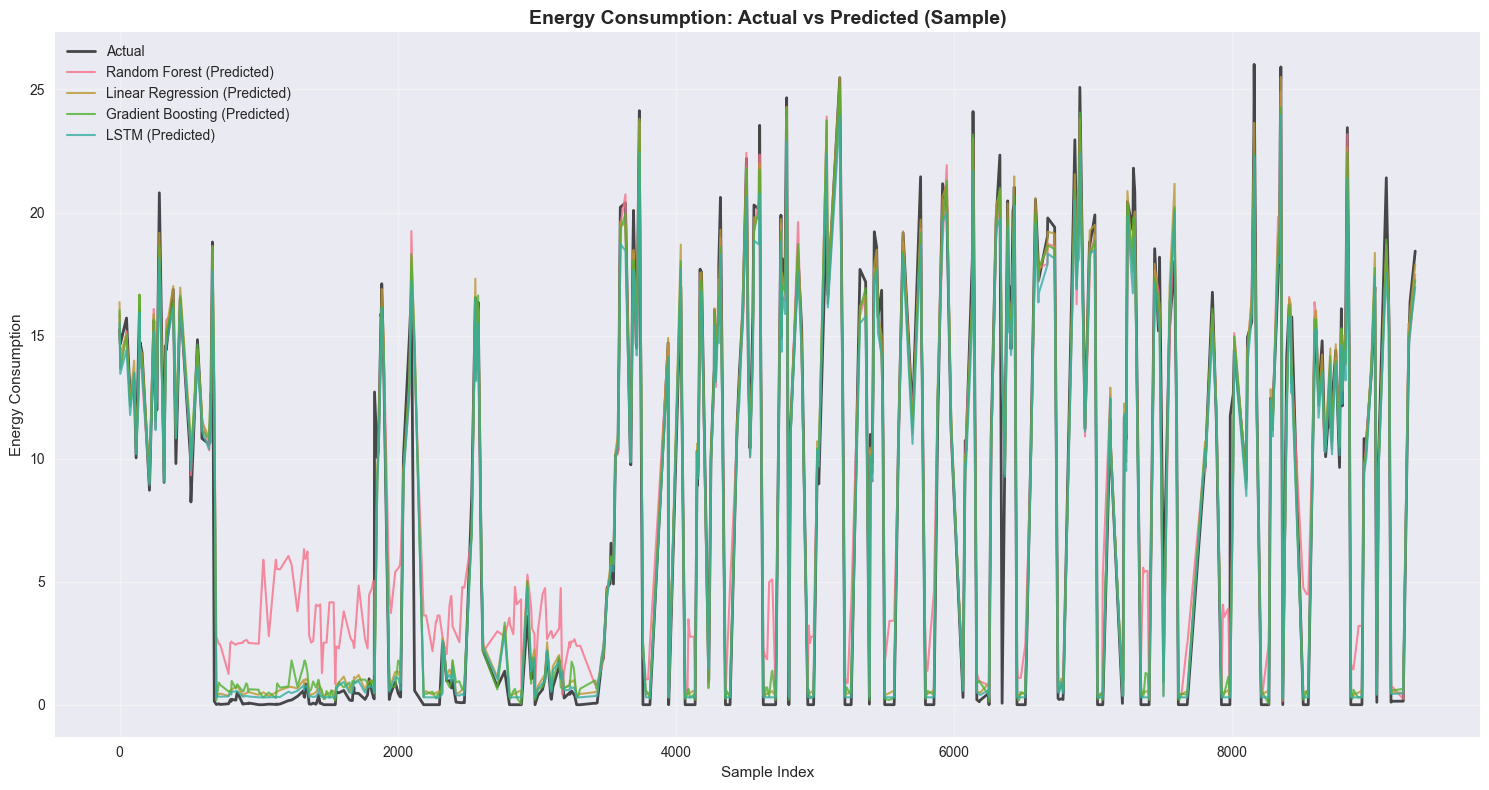

✓ Time series comparison saved as 'energy_timeseries_comparison.png'


In [29]:
# ============================================================
# STEP 16: TIME SERIES PREDICTION VISUALIZATION
# ============================================================

# Create time series plot for comparison
plt.figure(figsize=(15, 8))

# Sample a subset of data for visualization
sample_size = min(500, len(y_test))
sample_indices = np.random.choice(len(y_test), sample_size, replace=False)
sample_indices.sort()

plt.plot(sample_indices, y_test.iloc[sample_indices].values, 
         label='Actual', alpha=0.7, linewidth=2, color='black')

for i, (name, y_pred) in enumerate(predictions.items()):
    plt.plot(sample_indices, y_pred[sample_indices], 
            label=f'{name} (Predicted)', alpha=0.8, linewidth=1.5)

plt.title('Energy Consumption: Actual vs Predicted (Sample)', fontsize=14, fontweight='bold')
plt.xlabel('Sample Index')
plt.ylabel('Energy Consumption')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('../energy_timeseries_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

print("✓ Time series comparison saved as 'energy_timeseries_comparison.png'")

In [ ]:
# ============================================================
# STEP 17: SAVE MODELS
# ============================================================

print("\n" + "=" * 60)
print("SAVING TRAINED MODELS")
print("=" * 60)

import joblib
import os

# Create models directory if it doesn't exist
models_dir = "../models"
os.makedirs(models_dir, exist_ok=True)

# Save traditional ML models
for name, model in models.items():
    if name != 'LSTM':  # Skip LSTM as it's saved differently
        filename = f"{name.lower().replace(' ', '_')}_energy_model.pkl"
        filepath = os.path.join(models_dir, filename)
        joblib.dump(model, filepath)
        print(f"✓ {name} saved as '{filename}'")

# Save LSTM model if available
if 'LSTM' in models:
    try:
        lstm_path = os.path.join(models_dir, "lstm_energy_model.h5")
        models['LSTM'].save(lstm_path)
        print(f"✓ LSTM saved as 'lstm_energy_model.h5'")
    except:
        print("⚠ LSTM model could not be saved")

# Save performance metrics
metrics_df = pd.DataFrame(metrics).T
metrics_path = os.path.join(models_dir, "model_performance_metrics.csv")
metrics_df.to_csv(metrics_path)
print(f"✓ Performance metrics saved as 'model_performance_metrics.csv'")

# Save feature list
import json
features_path = os.path.join(models_dir, "model_features.json")
with open(features_path, 'w') as f:
    json.dump(available_features, f, indent=2)
print(f"✓ Feature list saved as 'model_features.json'")

print("\n" + "=" * 60)
print("ENERGY PREDICTION ANALYSIS COMPLETE!")
print("=" * 60)
print("Successfully trained and evaluated 4 ML models")
print("Generated comprehensive performance comparison")
print("Created visualizations for model analysis")
print("Saved all trained models and metrics")
print("Ready for deployment in web application")
print(f"\nBest performing model: {overall_best}")
print(f"Best R² Score: {best_r2[1]['R²']:.4f}")


SAVING TRAINED MODELS
✓ Random Forest saved as 'random_forest_energy_model.pkl'
✓ Linear Regression saved as 'linear_regression_energy_model.pkl'
✓ Gradient Boosting saved as 'gradient_boosting_energy_model.pkl'
✓ LSTM saved as 'lstm_energy_model.h5'
✓ Performance metrics saved as 'model_performance_metrics.csv'
✓ Feature list saved as 'model_features.json'

🎉 ENERGY PREDICTION ANALYSIS COMPLETE!
✅ Successfully trained and evaluated 4 ML models
✅ Generated comprehensive performance comparison
✅ Created visualizations for model analysis
✅ Saved all trained models and metrics
✅ Ready for deployment in web application

🏆 Best performing model: Gradient Boosting
📊 Best R² Score: 0.9699
